In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv
/kaggle/input/digit-recognizer/sample_submission.csv


In [2]:
TrainingData = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

In [3]:
X_train = TrainingData.iloc[:,1:]

In [4]:
y_train = TrainingData.iloc[:,:1]

In [5]:
#Scale
X_train = X_train.astype(float) / 255.

In [6]:
X_train.shape

(42000, 784)

In [7]:
y_train_cat.shape

NameError: name 'y_train_cat' is not defined

In [8]:
import tensorflow as tf
y_train_cat = tf.keras.utils.to_categorical(y_train)

In [9]:
def mlp_clf():
    # define two sets of inputs
    input_layer = tf.keras.layers.Input(shape=(784)) 
    
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.PReLU() ,  kernel_initializer='normal')(input_layer)
    mod1 = tf.keras.layers.BatchNormalization()(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.LeakyReLU() , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.Dropout(0.1)(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation="relu" , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.BatchNormalization()(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.PReLU() , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.Dropout(0.1)(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation="relu" , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.BatchNormalization()(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.PReLU() , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.Dropout(0.1)(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation="relu" , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.BatchNormalization()(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.PReLU() , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.Dropout(0.1)(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation="relu" , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.BatchNormalization()(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.PReLU() , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.Dropout(0.1)(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation=tf.keras.layers.LeakyReLU() , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.BatchNormalization()(mod1)
    mod1 = tf.keras.layers.Dense(units=1000, activation="relu" , kernel_initializer='normal')(mod1)
    mod1 = tf.keras.layers.Dropout(0.1)(mod1)
    output_layer = tf.keras.layers.Dense(10, activation="softmax" , kernel_initializer='normal')(mod1)
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,  optimizer=tf.keras.optimizers.Adam(), metrics=[tf.keras.metrics.CategoricalAccuracy()])
    return model

In [10]:
model = mlp_clf()

In [11]:
history = model.fit(x=X_train,y=y_train_cat, epochs=100,batch_size=256,validation_split=0.2,shuffle=True)

Epoch 1/100
132/132 [==============================] - 41s 312ms/step - loss: 0.4366 - categorical_accuracy: 0.8751 - val_loss: 0.4080 - val_categorical_accuracy: 0.8869
Epoch 2/100
132/132 [==============================] - 42s 317ms/step - loss: 0.1432 - categorical_accuracy: 0.9579 - val_loss: 0.2545 - val_categorical_accuracy: 0.9400
Epoch 3/100
132/132 [==============================] - 40s 304ms/step - loss: 0.1437 - categorical_accuracy: 0.9607 - val_loss: 0.2351 - val_categorical_accuracy: 0.9555
Epoch 4/100
132/132 [==============================] - 39s 294ms/step - loss: 0.0837 - categorical_accuracy: 0.9750 - val_loss: 0.1134 - val_categorical_accuracy: 0.9702
Epoch 5/100
132/132 [==============================] - 40s 303ms/step - loss: 0.0619 - categorical_accuracy: 0.9813 - val_loss: 0.1210 - val_categorical_accuracy: 0.9665
Epoch 6/100
132/132 [==============================] - 40s 299ms/step - loss: 0.0595 - categorical_accuracy: 0.9812 - val_loss: 0.1289 - val_categoric

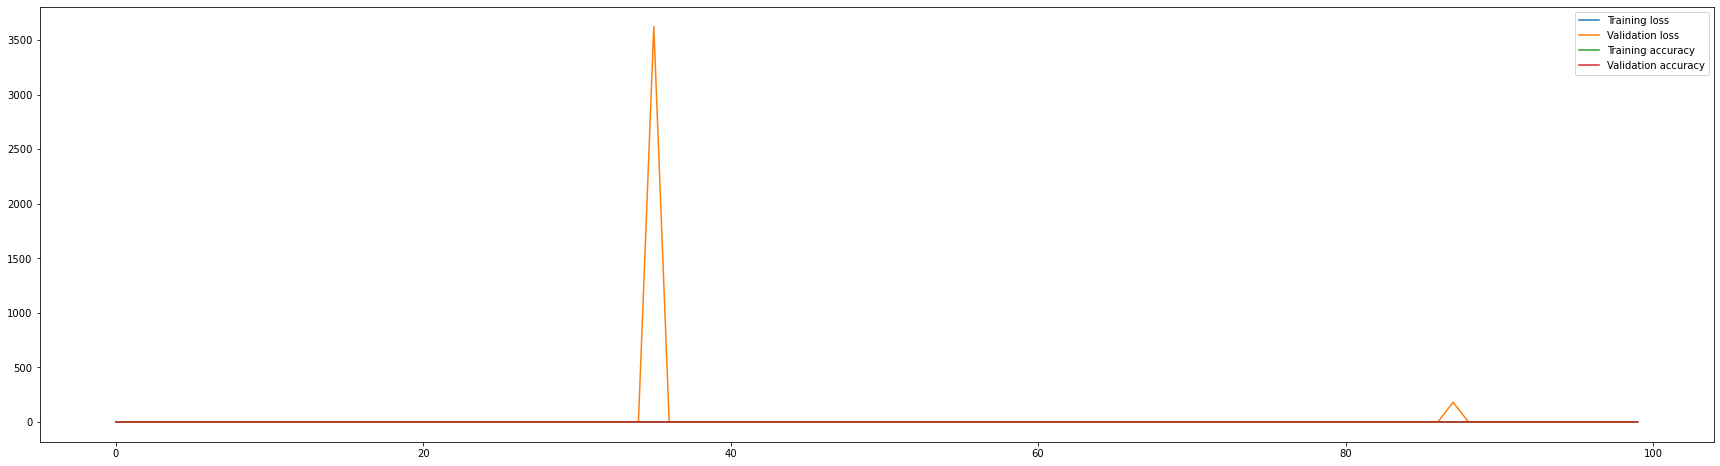

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,8))
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.plot(history.history['categorical_accuracy'], label="Training accuracy")
plt.plot(history.history['val_categorical_accuracy'], label="Validation accuracy")
plt.legend()
plt.show()

In [13]:
TestData = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [14]:
# Scale
X_test = TestData.astype(float) / 255.

In [15]:
# predict results
results = model.predict(X_test)

# select the indix with the maximum probability
results = np.argmax(results,axis = 1)

results = pd.Series(results,name="Label")


In [16]:
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)

submission.to_csv("cnn_mnist_pred.csv",index=False)